# 0.Setting up the environment

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv


# 1.Dummy Model Setup

In [2]:
# df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv") 
# X_test = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv") 

# X = df.drop("purchaseValue", axis=1) 
# y = df['purchaseValue'] 

# from sklearn.dummy import DummyRegressor 

# model = DummyRegressor().fit(X,y) 
# y_pred=model.predict(X_test) 

# submission = pd.DataFrame({"id": range(0,X_test.shape[0]), "purchaseValue": y_pred})
# submission.to_csv('submissionn.csv',index=False)

# 2.Data Loading,Visualization and Preprocessing

## Load the data

In [3]:
#to display all the columns
pd.set_option('display.max_columns', None)

In [4]:
train = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv")
print("Train data shape:",train.shape)

Train data shape: (116023, 52)


In [5]:
train.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,userId,trafficSource.campaign,device.mobileDeviceMarketingName,geoNetwork.networkDomain,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,geoNetwork.region,trafficSource,totals.visits,geoNetwork.networkLocation,sessionId,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,browserMajor,locationCountry,device.browserSize,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,geoNetwork.city,trafficSource.adwordsClickInfo.page,geoNetwork.metro,pageViews,locationZone,device.mobileDeviceModel,trafficSource.referralPath,totals.bounces,date,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,61421,(not set),not available in demo dataset,domain1,0,not available in demo dataset,1,not available in demo dataset,Washington,youtube.com,1,not available in demo dataset,1500100799,Windows,Northern America,referral,NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Redmond,NaN,Seattle-Tacoma WA,1.0,8,not available in demo dataset,/intl/hr/yt/about/,1.0,20170714,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,72287,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,California,(direct),1,not available in demo dataset,1495262065,Macintosh,Northern America,(none),NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Mountain View,NaN,San Francisco-Oakland-San Jose CA,1.0,8,not available in demo dataset,NaN,1.0,20170519,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,25180,(not set),not available in demo dataset,domain1,0,not available in demo dataset,2,not available in demo dataset,Lombardy,google,1,not available in demo dataset,1508510328,Windows,Southern Europe,organic,NaN,not available in demo dataset,Italy,not available in demo dataset,NaN,Not Socially Engaged,Milan,NaN,(not set),6.0,8,not available in demo dataset,NaN,NaN,20171020,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,41295,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,not available in demo dataset,youtube.com,1,not available in demo dataset,1483431838,Windows,Eastern Asia,referral,NaN,not available in demo dataset,Japan,not available in demo dataset,NaN,Not Socially Engaged,not available in demo dataset,NaN,not available in demo dataset,1.0,8,not available in demo dataset,/yt/about/ja/,1.0,20170103,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,113697,(not set),not available in demo dataset,domain1,0,not available 

In [6]:
test=pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv")
print("Test data shape:",test.shape)

Test data shape: (29006, 51)


In [7]:
test.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,userChannel,date,browser,device.browserSize,device.browserVersion,deviceType,device.flashVersion,device.isMobile,device.language,device.mobileDeviceBranding,device.mobileDeviceMarketingName,device.mobileDeviceModel,device.mobileInputSelector,os,device.operatingSystemVersion,device.screenColors,device.screenResolution,geoNetwork.city,geoNetwork.continent,locationCountry,geoNetwork.metro,geoNetwork.networkDomain,geoNetwork.networkLocation,geoNetwork.region,geoNetwork.subContinent,socialEngagementType,totals.bounces,totalHits,new_visits,pageViews,totals.visits,trafficSource.adContent,trafficSource.adwordsClickInfo.adNetworkType,trafficSource.adwordsClickInfo.isVideoAd,trafficSource.adwordsClickInfo.page,trafficSource.adwordsClickInfo.slot,trafficSource.campaign,trafficSource.isTrueDirect,trafficSource.keyword,trafficSource.medium,trafficSource.referralPath,trafficSource,sessionId,sessionNumber,sessionStart,userId,locationZone,geoCluster,browserMajor,screenSize,gclIdPresent
0,Social,20170508,Chrome,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,Windows,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,Americas,United States,not available in demo dataset,domain2,not available in demo dataset,not available in demo dataset,Northern America,Not Socially Engaged,NaN,11,NaN,10.0,1,NaN,NaN,NaN,NaN,NaN,(not set),True,NaN,referral,/a/google.com/forum/,groups.google.com,1494262567,2,1494262567,59555,8,Region_2,not available in demo dataset,medium,0
1,Organic Search,20170405,Chrome,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,Windows,not available in demo dataset,not available in demo dataset,not available in demo dataset,Palo Alto,Americas,United States,San Francisco-Oakland-San Jose CA,domain1,not available in demo dataset,California,Northern America,Not Socially Engaged,NaN,9,1.0,9.0,1,NaN,NaN,NaN,NaN,NaN,(not set),NaN,(not provided),organic,NaN,google,1491433811,1,1491433811,6394,8,Region_1,not available in demo dataset,medium,0
2,Organic Search,20170308,Safari,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,Macintosh,not available in demo dataset,not available in demo dataset,not available in demo dataset,Philadelphia,Americas,United States,Philadelphia PA,domain2,not available in demo dataset,Pennsylvania,Northern America,Not Socially Engaged,NaN,2,1.0,2.0,1,NaN,NaN,NaN,NaN,NaN,(not set),NaN,(not provided),organic,NaN,google,1489001815,1,1489001815,38969,8,Region_5,not available in demo dataset,medium,0
3,Referral,20171113,Chrome,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,Chrome OS,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,Americas,United States,not available in demo dataset,domain2,not available in demo dataset,not available in demo dataset,Northern America,Not Socially Engaged,NaN,3,NaN,3.0,1,NaN,NaN,NaN,NaN,NaN,(not set),True,NaN,referral,/document/d/1GSpeJSCBhxRNya7kiUbBKO3rR20jBBBF3...,docs.google.com,1510593024,30,1510593024,120027,8,Region_2,not available in demo dataset,medium,0
4,Organic Search,20161212,Chrome,not available in demo dataset,not available in demo da

## Performing EDA

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       116023 non-null  object 
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   11

#### Check for missing values

In [9]:
#check the percentage of missing values.
missing_values=train.isnull().mean().sort_values(ascending=False) *100
print(missing_values[missing_values > 0])

trafficSource.adContent                         97.446196
trafficSource.adwordsClickInfo.isVideoAd        96.310214
trafficSource.adwordsClickInfo.page             96.310214
trafficSource.adwordsClickInfo.adNetworkType    96.310214
trafficSource.adwordsClickInfo.slot             96.310214
trafficSource.referralPath                      63.184886
trafficSource.isTrueDirect                      63.033192
trafficSource.keyword                           61.936857
totals.bounces                                  59.363230
new_visits                                      30.601691
pageViews                                        0.006895
dtype: float64


Observation: The first five features have more than 90% missing columns

### Handling missing values

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(include=['object', 'bool']).columns

original_dtypes = train.dtypes.to_dict()

num_imp = SimpleImputer(strategy='constant', fill_value=0)
cat_imp = SimpleImputer(strategy='constant', fill_value='missing')

preprocessor = ColumnTransformer([
    ('num', num_imp, num_cols),
    ('cat', cat_imp, cat_cols)
])


X_prepared = preprocessor.fit_transform(train)

train_processed = pd.DataFrame(X_prepared, columns=num_cols.tolist() + cat_cols.tolist())

for col in train_processed.columns:
    train_processed[col] = train_processed[col].astype(original_dtypes[col])

In [11]:
train_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   purchaseValue                                 116023 non-null  float64
 1   userId                                        116023 non-null  int64  
 2   gclIdPresent                                  116023 non-null  int64  
 3   sessionNumber                                 116023 non-null  int64  
 4   totals.visits                                 116023 non-null  int64  
 5   sessionId                                     116023 non-null  int64  
 6   trafficSource.adwordsClickInfo.page           116023 non-null  float64
 7   pageViews                                     116023 non-null  float64
 8   locationZone                                  116023 non-null  int64  
 9   totals.bounces                                11

In [12]:
# Total duplicate rows
duplicate_rows = train_processed.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum())

Number of duplicate rows: 236


In [13]:
#check the dimension of the train dataset.
train_processed.shape

(116023, 52)

In [14]:
#Describe the numerical columns
train_processed.describe()

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,new_visits
count,1.160230e+05,116023.000000,116023.000000,116023.000000,116023.0,1.160230e+05,116023.000000,116023.000000,116023.0,116023.000000,1.160230e+05,116023.000000,1.160230e+05,116023.000000
mean,2.656393e+07,61094.356231,0.037019,2.691311,1.0,1.493429e+09,0.037622,8.411772,8.0,0.406368,2.016860e+07,10.607371,1.493429e+09,0.693983
std,2.051825e+08,35240.756859,0.188808,10.451613,0.0,1.528798e+07,0.195111,14.344612,0.0,0.491157,6.182322e+03,19.629576,1.528798e+07,0.460839
min,0.000000e+00,0.000000,0.000000,1.000000,1.0,1.470035e+09,0.000000,0.000000,8.0,0.000000,2.016080e+07,1.000000,1.470035e+09,0.000000
25%,0.000000e+00,30603.500000,0.000000,1.000000,1.0,1.480066e+09,0.000000,1.000000,8.0,0.000000,2.016112e+07,1.000000,1.480066e+09,0.000000
50%,0.000000e+00,61014.000000,0.000000,1.000000,1.0,1.491646e+09,0.000000,2.000000,8.0,0.000000,2.017041e+07,2.000000,1.491646e+09,1.000000
75%,0.000000e+00,91616.500000,0.000000,2.000000,1.0,1.505079e+09,0.000000,10.000000,8.0,1.000000,2.017091e+07,12.000000,1.505079e+09,1.000000
max,2.312950e+10,122276.000000,1.000000,447.000000,1.0,1.525157e+09,5.000000,469.000000,8.0,1.000000,2.018043e+07,500.000000,1.525157e+09,1.000000


In [15]:
#Describe the categorical columns. 
train_processed.describe(include="object")

,trafficSource.isTrueDirect,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,trafficSource.campaign,device.mobileDeviceMarketingName,geoNetwork.networkDomain,device.operatingSystemVersion,device.flashVersion,geoNetwork.region,trafficSource,geoNetwork.networkLocation,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,browserMajor,locationCountry,device.browserSize,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,geoNetwork.city,geoNetwork.metro,device.mobileDeviceModel,trafficSource.referralPath,device.language,deviceType,userChannel,device.browserVersion,device.screenColors,geoNetwork.continent
count,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023,116023
unique,2,34,1,54,567,1,5,4,1,1,28,1,3,1,1,388,161,1,18,23,7,2,1,193,1,3,1,695,104,1,942,1,3,8,1,1,6
top,missing,Chrome,not available in demo dataset,missing,missing,medium,Region_2,missing,not available in demo dataset,not available in demo dataset,(not set),not available in demo dataset,domain1,not available in demo dataset,not available in demo dataset,not available in demo dataset,google,not available in demo dataset,Windows,Northern America,organic,missing,not available in demo dataset,United States,not available in demo dataset,missing,Not Socially Engaged,not available in demo dataset,not available in demo dataset,not available in demo dataset,missing,not available in demo dataset,desktop,Organic Search,not available in demo dataset,not available in demo dataset,Americas
freq,73133,84508,116023,113060,71861,116023,23294,111742,116023,116023,110280,116023,38795,116023,116023,60138,44332,116023,39135,63596,40654,111742,116023,60369,116023,111742,116023,60138,60138,116023,73309,116023,86480,46925,116023,116023,69856


Observation:
1. There are 116023 rows and 52 columns in the training dataset.
2. There are 37 columns having datatype object,1 column with datatype boolean, 5 column having datatype float64 and 9 columns with datatype int64.
3. * In browser,Chrome has the highest frequency.
   * In screensize, medium is the only value.
   * In geoCluster ,Region2 has the highest frequency.
   * In geoNetwork.networkDomain, domain1 has the highest frequency.
   * In trafficSource,google has the highest frequency.
   * In os ,Windows has the highest frequency.
   * In geoNetwork.subContinent, North America has the highest frequency.
   * In deviceType, desktop has the highest frequency.
   * In geoNetwork.continent, Americas has the highest frequency.

## Data Visualization

### PurchaseValue

Purpose: To understand the distribution of purchaseValue column

In [16]:
train_processed['purchaseValue'].describe()

count    1.160230e+05
mean     2.656393e+07
std      2.051825e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.312950e+10
Name: purchaseValue, dtype: float64

In [17]:
percentage = (train_processed['purchaseValue'] == 0).mean() * 100
print(f"Percentage of zero values: {percentage:.2f}%")

Percentage of zero values: 79.33%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


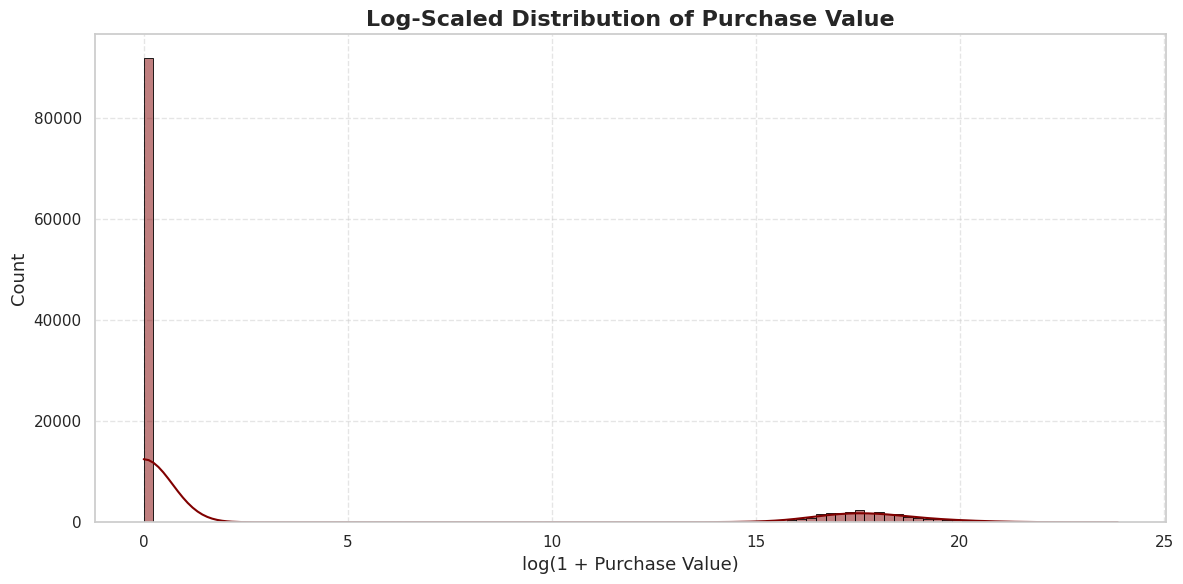

In [18]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

# Apply log1p transformation directly during plotting
sns.histplot(np.log1p(train_processed['purchaseValue']), bins=100, kde=True,
             color='maroon', edgecolor='black')

plt.title('Log-Scaled Distribution of Purchase Value', fontsize=16, weight='bold')
plt.xlabel('log(1 + Purchase Value)', fontsize=13)
plt.ylabel('Count', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Observation:
1. There's a very tall spike at the far left of the graph , suggesting that many purchase values are 0.
2. After the spike, there’s a long and thin tail extending to the right — this shows a small number of users have high purchase values.

### Correlation heatmap

Purpose:Identify relationships between numerical features and their correlation with the purchaseValue column.

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


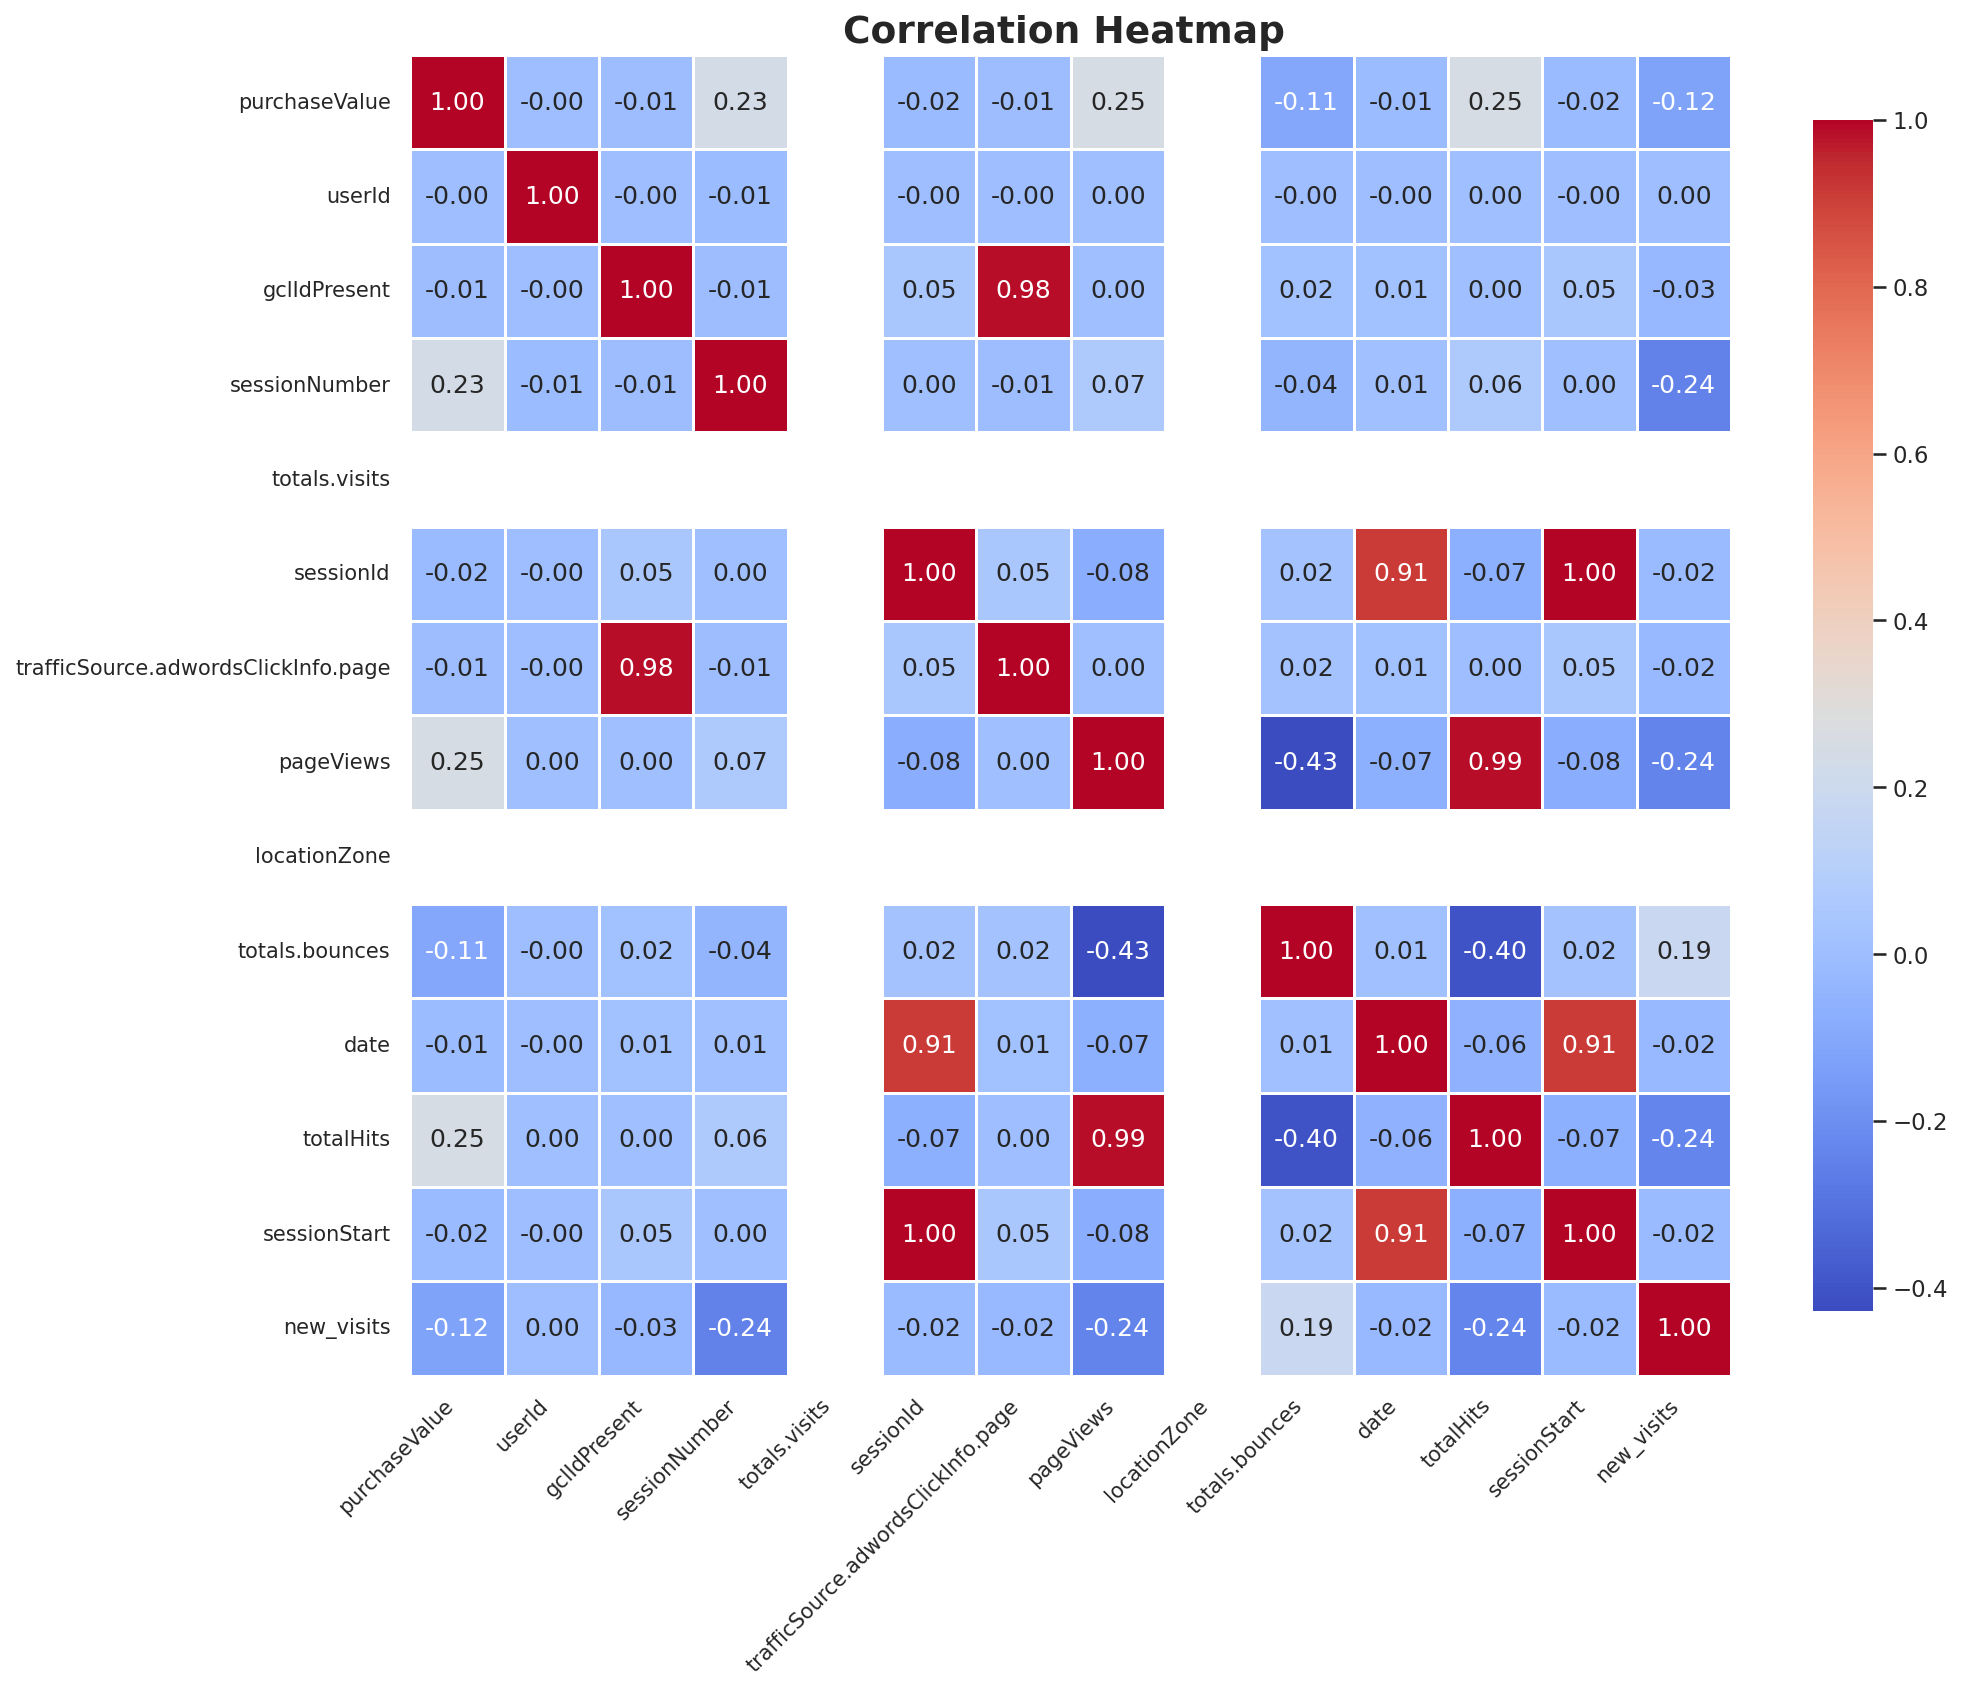

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric columns
train_numeric = train_processed.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = train_numeric.corr()

# Plotting
plt.figure(figsize=(14, 12), dpi=150)
sns.set(style="white")

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True
)

# Titles and labels
plt.title('Correlation Heatmap ', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


Observation:
* totals.visits and locationZone has constant values.

### Separating the features and target variable for further analysis.

In [20]:
X_train=train_processed.drop(columns=['purchaseValue'])
y_train=train_processed['purchaseValue']

# 3.Feature engineering

In [21]:
X_train['date'] = pd.to_datetime(X_train['date'], format='%Y%m%d')

# Extract date
X_train['dayofweek'] = X_train['date'].dt.dayofweek
X_train['month'] = X_train['date'].dt.month
X_train['year'] = X_train['date'].dt.year
X_train['is_weekend'] = (X_train['dayofweek'] >= 5).astype(int)

# Drop original date column
X_train.drop(columns=['date'], inplace=True)

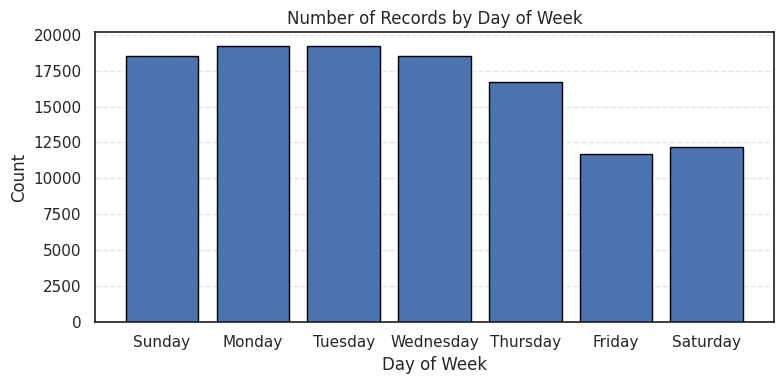

In [22]:
day_counts = X_train['dayofweek'].value_counts().sort_index()

order = [0, 1, 2, 3, 4, 5, 6]
labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

plt.figure(figsize=(8, 4))
plt.bar(order, day_counts.values, edgecolor='black')

plt.xticks(ticks=order, labels=labels)
plt.title('Number of Records by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [23]:
X_train['sessionStart_'] = pd.to_datetime(X_train['sessionStart'], unit='s')
X_train['hour'] = X_train['sessionStart_'].dt.hour
def get_daytime(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

X_train['daytime'] = X_train['hour'].apply(get_daytime)

X_train.drop(columns=['sessionStart_'], inplace=True)
X_train.drop(columns=['hour'], inplace=True)

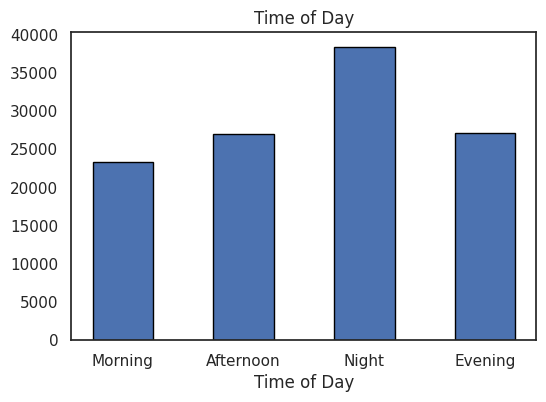

In [24]:
plt.figure(figsize=(6,4))
plt.hist(X_train['daytime'], bins=4, range=[0, 4], align='left', rwidth=0.5,edgecolor='black')
plt.title('Time of Day')
plt.xlabel('Time of Day')
plt.show()

Observation:
* Most of the purchase are made on Monday and Tuesday compared to other days.
* Most of the purchase are made during night.

# 4.Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [26]:
print(X_train_split.shape)
print(X_val_split.shape)
print(y_train_split.shape)
print(y_val_split.shape)

(92818, 55)
(23205, 55)
(92818,)
(23205,)


# 5.Data Pre-Processing on training and validation sets

In [27]:
# Dropping columns with missing values and columns having only a constant value in it.


drop=['trafficSource.adContent','trafficSource.adwordsClickInfo.slot',
    'trafficSource.adwordsClickInfo.adNetworkType',
    'trafficSource.adwordsClickInfo.isVideoAd','trafficSource.adwordsClickInfo.page',
    'trafficSource.referralPath','trafficSource.isTrueDirect','trafficSource.keyword',         

    'device.browserSize','device.browserVersion','device.screenColors','device.language',
     'device.mobileDeviceModel','socialEngagementType','browserMajor','geoNetwork.networkLocation','daytime',
    'device.flashVersion','device.operatingSystemVersion','geoNetwork.city','device.mobileDeviceMarketingName',
    'sessionNumber','device.mobileInputSelector','device.mobileDeviceBranding','device.screenResolution',
    'screenSize','locationZone','totals.visits','sessionId','device.isMobile',

#Dropping a few more columns that are irrelevant, redundant or  noisy. 

    'browser', 'trafficSource.campaign', 'geoNetwork.networkDomain','geoNetwork.region', 
      'trafficSource', 'os','geoNetwork.subContinent', 'trafficSource.medium',
       'locationCountry','geoNetwork.metro','deviceType','userChannel', 'geoNetwork.continent',
       'geoCluster']


X_train_split.drop(columns=drop, inplace=True)
X_val_split.drop(columns=drop, inplace=True)

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Select columns
numerical_cols = X_train_split.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train_split.select_dtypes(include=['object']).columns.tolist()

# Define pipelines
numerical_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine pipelines in ColumnTransformer
ct = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


In [29]:
X_train_split_processed= ct.fit_transform(X_train_split)
feature_names = ct.get_feature_names_out()
# Convert to DataFrame
X_train_split_processed_ = pd.DataFrame(X_train_split_processed, columns=feature_names)
print(X_train_split_processed_.shape)
# X_train_split_processed_=X_train_split
# print(X_train_split_processed_.shape)

(92818, 8)


In [30]:
X_val_split_processed= ct.transform(X_val_split)
feature_names = ct.get_feature_names_out()
# Convert to DataFrame
X_val_split_processed_ = pd.DataFrame(X_val_split_processed, columns=feature_names)
print(X_val_split_processed_.shape)
# X_val_split_processed_=X_val_split
# print(X_val_split_processed_.shape)

(23205, 8)


Using Random Forest Regressor to check feature importance because of its interpretability, robustness, and built-in ability to estimate how much each feature contributes to the model.

In [31]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train_split_processed_, y_train_split)


RandomForestRegressor(random_state=42)

In [32]:
import pandas as pd


feature_importance = pd.DataFrame({
    'feature': X_train_split_processed_.columns,
    'importance': model.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values('importance', ascending=False)

# top 10
print(feature_importance.head(12))


               feature  importance
0          num__userId    0.408108
5    num__sessionStart    0.301272
2       num__pageViews    0.141862
4       num__totalHits    0.130129
6      num__new_visits    0.013940
7      num__is_weekend    0.002999
1    num__gclIdPresent    0.001691
3  num__totals.bounces    0.000000


# 6.Testing Models

## Hyperparameter tuning for Random Forest Regressor

I am tuning Random Forest Regressor using RandomizedSearchCV to automatically search for the best hyperparameters that maximize the R² score on a 3-fold cross-validation.



In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 15,None],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}


rf = RandomForestRegressor(random_state=42)


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_split_processed_, y_train_split)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}


In [34]:
from sklearn.metrics import  r2_score

# Predict on validation set
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_val_split_processed_)

r2 = r2_score(y_val_split, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.2884


Observaion:
An R² score of 0.28 on the validation set means that the model explains only 28% of the variance in the target variable

## Hyperparameter tuning for XGBoost Regressor

Key Points:
* I used RandomizedSearchCV with XGBRegressor to efficiently tune key hyperparameters like n_estimators, max_depth, learning_rate, and regularization terms.
* This helps balance model complexity, prevent overfitting, and boost generalization.
* Cross-validation (cv=3) ensures the model performs consistently across different data splits.
* scoring='r2' focuses the search on maximizing how well the model explains variance in the target.

In [35]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],    
    'reg_lambda': [1, 1.5, 2],       
}

xgb = XGBRegressor(random_state=42)

xg_random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xg_random_search.fit(X_train_split_processed_, y_train_split)
print("Best R²:", xg_random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best R²: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [36]:
best_xg = xg_random_search.best_estimator_
y_pred = best_xg.predict(X_val_split_processed_)

r2 = r2_score(y_val_split, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.2973


## Extra Trees Regressor

Hyperparameter tuning was not done for this model .

In [37]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Initialize
et_model = ExtraTreesRegressor(n_estimators=550, random_state=42, n_jobs=-1)

et_model.fit(X_train_split_processed_, y_train_split)
test_preds= et_model.predict(X_val_split_processed_)

print("R² Score:", r2_score(y_val_split, test_preds))

R² Score: 0.30035549432991104


# 7.Make predictions using best performing model

### Training model on Full Train data

In [38]:
X_train.drop(columns=drop, inplace=True)

In [39]:
X_train.columns

Index(['userId', 'gclIdPresent', 'pageViews', 'totals.bounces', 'totalHits',
       'sessionStart', 'new_visits', 'dayofweek', 'month', 'year',
       'is_weekend'],
      dtype='object')

In [40]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Initialize the model
et_model = ExtraTreesRegressor(n_estimators=129, random_state=42, n_jobs=-1)

et_model.fit(X_train, y_train)

ExtraTreesRegressor(n_estimators=129, n_jobs=-1, random_state=42)

# 8.To generate CSV File.

In [41]:
#Reindexing test data columns to match train data
test = test.reindex(columns=train_processed.columns)
test=test.drop(columns=['purchaseValue'])

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_cols = test.select_dtypes(include=['number']).columns
cat_cols = test.select_dtypes(include=['object', 'bool']).columns

original_dtypes = test.dtypes.to_dict()

num_imp = SimpleImputer(strategy='constant', fill_value=0)
cat_imp = SimpleImputer(strategy='constant', fill_value='missing')

preprocessor = ColumnTransformer([
    ('num', num_imp, num_cols),
    ('cat', cat_imp, cat_cols)
])

test_prepared = preprocessor.fit_transform(test)

test_processed = pd.DataFrame(test_prepared, columns=num_cols.tolist() + cat_cols.tolist())

for col in test_processed.columns:
    test_processed[col] = test_processed[col].astype(original_dtypes[col])

In [43]:
test_processed['date'] = pd.to_datetime(test_processed['date'], format='%Y%m%d')

# Extract date
test_processed['dayofweek'] = test_processed['date'].dt.dayofweek
test_processed['month'] = test_processed['date'].dt.month
test_processed['year'] = test_processed['date'].dt.year
test_processed['is_weekend'] = (test_processed['dayofweek'] >= 5).astype(int)

# Drop original date column
test_processed.drop(columns=['date'], inplace=True)

In [44]:
test_processed['sessionStart_'] = pd.to_datetime(test_processed['sessionStart'], unit='s')
test_processed['hour'] = test_processed['sessionStart_'].dt.hour
def get_daytime(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

test_processed['daytime'] = test_processed['hour'].apply(get_daytime)

test_processed.drop(columns=['sessionStart_'], inplace=True)
test_processed.drop(columns=['hour'], inplace=True)

In [45]:
test_processed.drop(columns=drop, inplace=True)

In [46]:
et_preds = et_model.predict(test_processed)

In [47]:
submission = pd.DataFrame({"id": range(len(et_preds)), "purchaseValue": et_preds})
submission.to_csv("submission.csv", index=False)

In [48]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# categorical=data.select_dtypes(['object'])



# categorical_pipeline=Pipeline(steps=[OneHotEncoder()

# processed_data=ColumnTransformer([
#     "cat",categorical,categorical_pipeline
# ])


# data_preprocessed=processed_data.fit(data)